<a href="https://colab.research.google.com/github/Keistkmiya/Tugas2-Scikit_learn_Cookbook/blob/main/Tugas2_Chapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Advanced Classifier Tuning and Evaluation

## Cross-Validation for Robust Performance Evaluation

Membagi data menjadi data latih dan data uji secara konvensional terkadang bisa menghasilkan estimasi performa yang bias, tergantung pada bagaimana data tersebut terbagi. Cross-Validation (Validasi Silang), khususnya k-fold cross-validation, mengatasi masalah ini dengan membagi dataset menjadi k bagian (fold) yang sama besar. Model akan dilatih sebanyak k kali, di mana pada setiap iterasi, satu fold yang berbeda digunakan sebagai data uji (validasi) dan k-1 fold sisanya digunakan sebagai data latih. Hasil evaluasi akhir merupakan rata-rata dari k skor tersebut, memberikan gambaran performa model yang jauh lebih stabil dan objektif.

In [1]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

model = LogisticRegression()
scores = cross_val_score(model, X, y, cv=3)

print(scores)
print(scores.mean())

[0.75       1.         0.66666667]
0.8055555555555555


## Tuning Hyperparameters with Grid Search

Setiap algoritma machine learning memiliki hyperparameter yang harus ditentukan sebelum proses pelatihan dimulai, dan kombinasi nilai yang tepat sangat memengaruhi performa model. Grid Search adalah metode optimasi hyperparameter yang bekerja secara menyeluruh (exhaustive search) dengan mencoba semua kemungkinan kombinasi nilai yang didefinisikan dalam sebuah kamus (grid). Scikit-learn menyediakan GridSearchCV yang secara otomatis akan melatih model pada setiap kombinasi tersebut, mengevaluasinya menggunakan teknik Cross-Validation, dan mengembalikan kombinasi hyperparameter terbaik yang menghasilkan skor performa tertinggi.

In [2]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

X = np.array([[1, 2], [2, 3], [3, 4], [5, 6], [6, 7], [7, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_search = GridSearchCV(SVC(), param_grid, cv=2)
grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 0.1, 'kernel': 'linear'}
1.0


## Evaluating Classifiers with a Confusion Matrix

Akurasi saja sering kali tidak cukup untuk mengevaluasi performa model klasifikasi, terutama jika dataset yang digunakan tidak seimbang (imbalanced data). Confusion Matrix (Matriks Kebingungan) adalah tabel tabel evaluasi yang membandingkan nilai aktual (ground truth) dengan nilai hasil prediksi model. Matriks ini memecah hasil prediksi menjadi empat kuadran krusial: True Positive (TP), True Negative (TN), False Positive (FP/Type I Error), dan False Negative (FN/Type II Error). Dari matriks ini, kita bisa menghitung metrik evaluasi yang lebih mendalam seperti Precision, Recall, dan F1-Score.

In [3]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.array([0, 0, 1, 1, 0, 1, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0, 1, 0])

matrix = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

print("Confusion Matrix:")
print(matrix)
print("\nClassification Report:")
print(report)

Confusion Matrix:
[[3 1]
 [1 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



## Evaluating Classifiers with Receiver Operating Characteristic (ROC) Curves

Kurva ROC (Receiver Operating Characteristic) adalah grafik yang digunakan untuk mengevaluasi performa model klasifikasi biner pada berbagai nilai ambang batas (threshold). Kurva ini memetakan True Positive Rate (TPR/Recall) pada sumbu Y dan False Positive Rate (FPR) pada sumbu X. Area di bawah kurva ini disebut AUC (Area Under the Curve). Nilai AUC berkisar antara 0 hingga 1, di mana nilai mendekati 1 menandakan model memiliki kemampuan yang sangat baik dalam memisahkan kedua kelas, sedangkan nilai 0.5 berarti model tidak lebih baik daripada tebakan acak.

AUC Score: 0.875


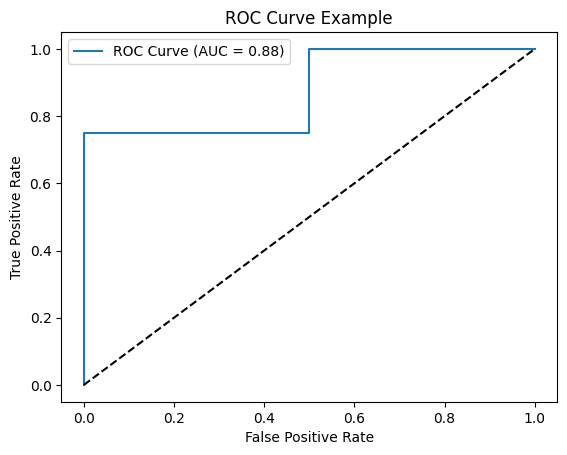

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.2, 0.9, 0.5, 0.7])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)

print(f"AUC Score: {auc_score}")

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Example')
plt.legend()
plt.show()